In [1]:
%pip install -r ../requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
%pip install matplotlib seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


C:\Users\rahel\AppData\Local\Temp\ipykernel_14340\4151926946.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="total_medals", y="country", data=top10_df, palette="magma")


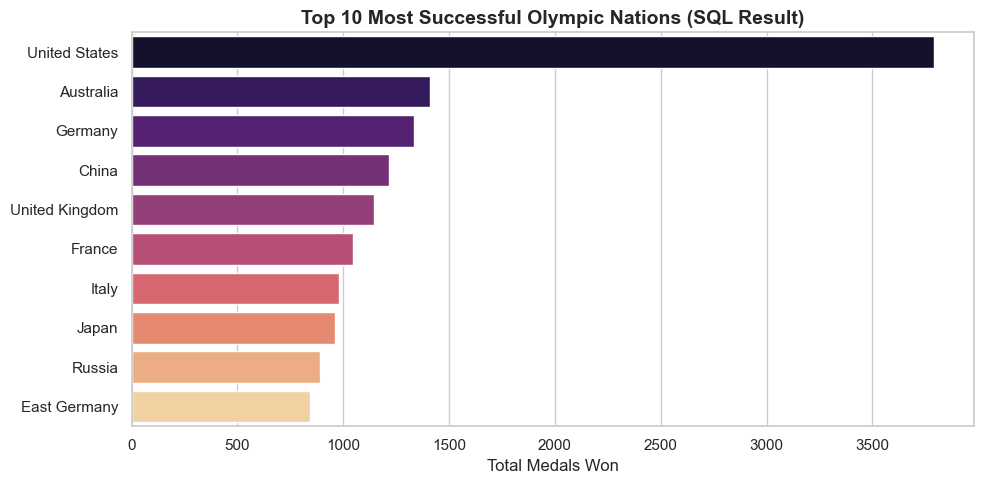

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import sqlite3
import os

# Set visualization style
sns.set_theme(style="whitegrid")
os.makedirs("../charts", exist_ok=True)

# 1. TOP 10 COUNTRIES (SQL QUERY)

# Connecting to the SQLite database generated by the pipeline
conn = sqlite3.connect("../data/processed/olympics.db")
query = """
SELECT country, SUM(medals_total) AS total_medals
FROM olympics_final
GROUP BY country
ORDER BY total_medals DESC
LIMIT 10;
"""
top10_df = pd.read_sql_query(query, conn)
conn.close()

plt.figure(figsize=(10, 5))
sns.barplot(x="total_medals", y="country", data=top10_df, palette="magma")
plt.title("Top 10 Most Successful Olympic Nations (SQL Result)", fontsize=14, fontweight="bold")
plt.xlabel("Total Medals Won")
plt.ylabel("")
plt.tight_layout()
plt.savefig("../charts/top10_countries.png", dpi=150)
plt.show()


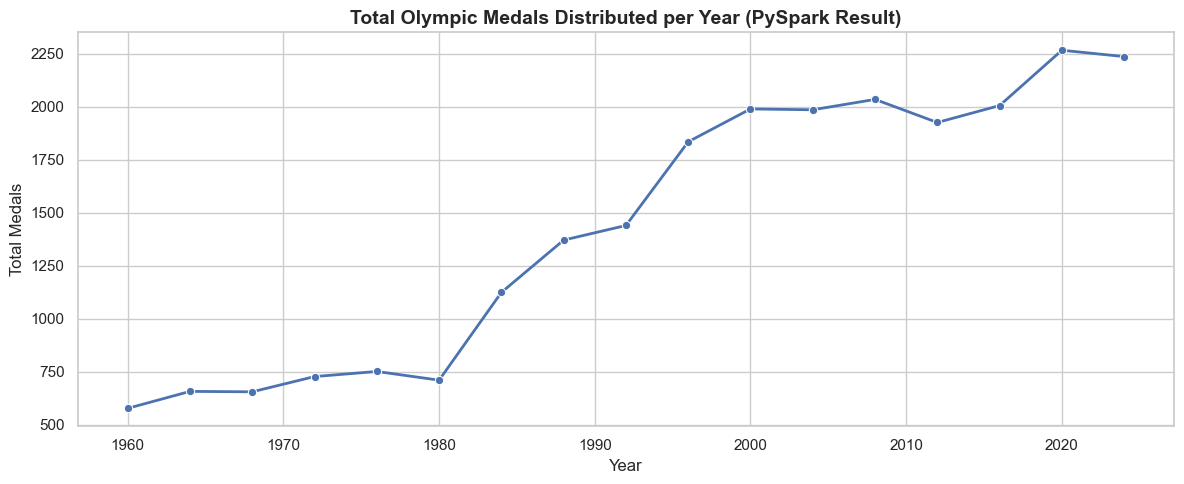

In [4]:
# 2. MEDAL INFLATION OVER TIME (APACHE SPARK RESULT)

# Reading the chronological data processed by PySpark.
spark_df = pd.read_csv("../data/processed/medals_by_year.csv")

plt.figure(figsize=(12, 5))
sns.lineplot(x="year", y="total_medals", data=spark_df, marker="o", color="b", linewidth=2)
plt.title("Total Olympic Medals Distributed per Year (PySpark Result)", fontsize=14, fontweight="bold")
plt.xlabel("Year")
plt.ylabel("Total Medals")
plt.tight_layout()
plt.savefig("../charts/medal_inflation.png", dpi=150)
plt.show()


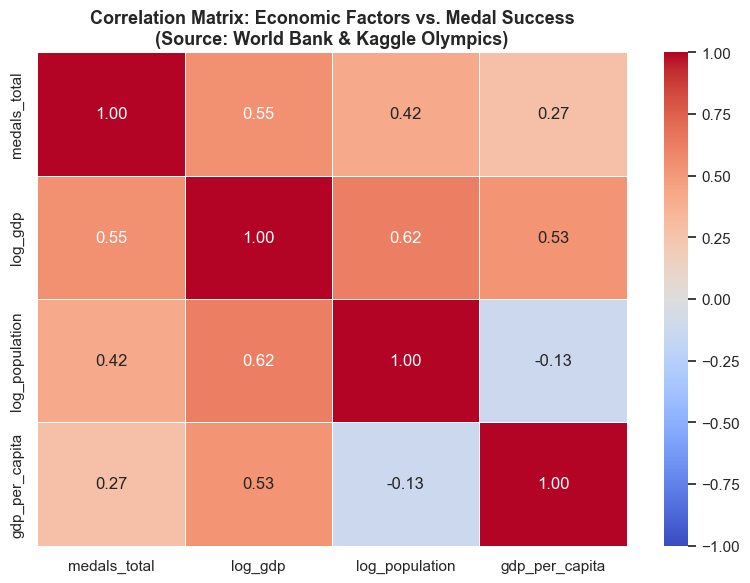

In [5]:
# 3. MACROECONOMIC CORRELATION HEATMAP (WEALTH & POPULATION)
final_df = pd.read_csv("../data/processed/final_dataset.csv")

# Using logarithmic values to balance extreme global disparities
econ_cols = ["medals_total", "log_gdp", "log_population", "gdp_per_capita"]
econ_data = final_df[econ_cols].dropna()

plt.figure(figsize=(8, 6))
sns.heatmap(
    econ_data.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5,
    vmin=-1,
    vmax=1,
)
plt.title("Correlation Matrix: Economic Factors vs. Medal Success\n(Source: World Bank & Kaggle Olympics)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("../charts/correlation_heatmap.png", dpi=150)
plt.show()


C:\Users\rahel\AppData\Local\Temp\ipykernel_14340\312475311.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="host_flag", y="medals_total", data=host_comparison, palette="viridis")


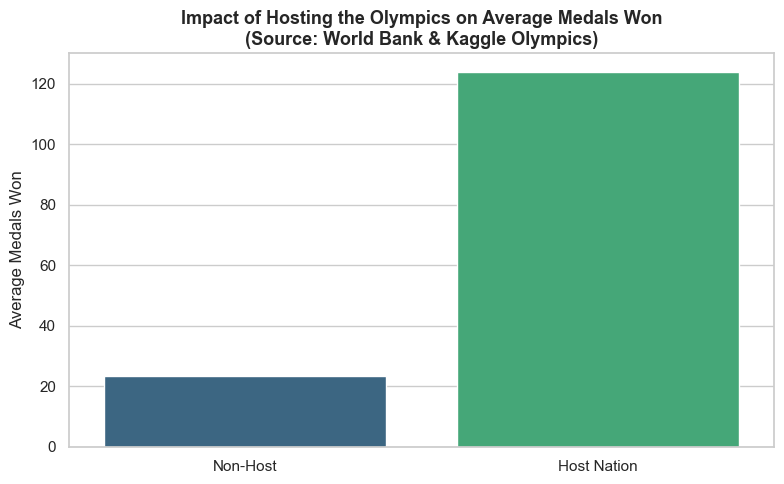

In [6]:
# 4. HOST COUNTRY EFFECT

host_comparison = (
    final_df.groupby("host_flag")["medals_total"]
    .mean()
    .reset_index()
)
host_comparison["host_flag"] = host_comparison["host_flag"].map({0: "Non-Host", 1: "Host Nation"})

plt.figure(figsize=(8, 5))
sns.barplot(x="host_flag", y="medals_total", data=host_comparison, palette="viridis")
plt.title("Impact of Hosting the Olympics on Average Medals Won\n(Source: World Bank & Kaggle Olympics)", fontsize=13, fontweight="bold")
plt.ylabel("Average Medals Won")
plt.xlabel("")
plt.tight_layout()
plt.savefig("../charts/host_effect.png", dpi=150)
plt.show()


The cells below run:
1. **OLS Regression** — quantifies each factor's independent contribution
2. **Mann-Whitney U Test** — statistically tests the host-country advantage
3. **Random Forest** — predicts medal counts and ranks feature importances


In [7]:
# 5. OLS REGRESSION — GDP, Population, Host Flag → Medals
import numpy as np
import statsmodels.formula.api as smf

# Include "year" so the Random Forest cell can use it for a temporal split
model_df = final_df[
    ["year", "medals_total", "log_gdp", "log_population", "host_flag"]
].dropna().copy()

ols = smf.ols(
    "medals_total ~ log_gdp + log_population + host_flag",
    data=model_df,
).fit()

print(ols.summary())


                            OLS Regression Results                            
Dep. Variable:           medals_total   R-squared:                       0.353
Model:                            OLS   Adj. R-squared:                  0.351
Method:                 Least Squares   F-statistic:                     176.2
Date:                Fri, 01 May 2026   Prob (F-statistic):           3.76e-91
Time:                        10:02:19   Log-Likelihood:                -4864.8
No. Observations:                 972   AIC:                             9738.
Df Residuals:                     968   BIC:                             9757.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                     coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------
Intercept       -281.0207     15.260    -18.

In [8]:
# 6. STATISTICAL TEST — Host Country Advantage (Mann-Whitney U)
from scipy import stats

host = final_df[final_df["host_flag"] == 1]["medals_total"].dropna()
non_host = final_df[final_df["host_flag"] == 0]["medals_total"].dropna()

stat, p_value = stats.mannwhitneyu(host, non_host, alternative="greater")

# Cohen's d effect size
pooled_std = np.sqrt(
    (host.std() ** 2 + non_host.std() ** 2) / 2
)
cohens_d = (host.mean() - non_host.mean()) / pooled_std

print("=== Host Country Advantage — Mann-Whitney U Test ===")
print(f"Host nations   — mean medals: {host.mean():.1f}, n={len(host)}")
print(f"Non-host nations — mean medals: {non_host.mean():.1f}, n={len(non_host)}")
print(f"U statistic: {stat:.0f}")
print(f"p-value (one-tailed, host > non-host): {p_value:.4f}")
print(f"Cohen's d effect size: {cohens_d:.2f}")
if p_value < 0.05:
    print("→ Statistically significant host-country advantage (p < 0.05).")
else:
    print("→ No statistically significant host-country advantage at α=0.05.")


=== Host Country Advantage — Mann-Whitney U Test ===
Host nations   — mean medals: 123.9, n=16
Non-host nations — mean medals: 23.3, n=956
U statistic: 13840
p-value (one-tailed, host > non-host): 0.0000
Cohen's d effect size: 1.39
→ Statistically significant host-country advantage (p < 0.05).


=== Random Forest — Test Set Performance ===
Train size: 726 | Test size: 246
MAE:  19.41 medals
RMSE: 30.41 medals


C:\Users\rahel\AppData\Local\Temp\ipykernel_14340\4143861360.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="importance", y="feature", data=importance_df, palette="Blues_d")


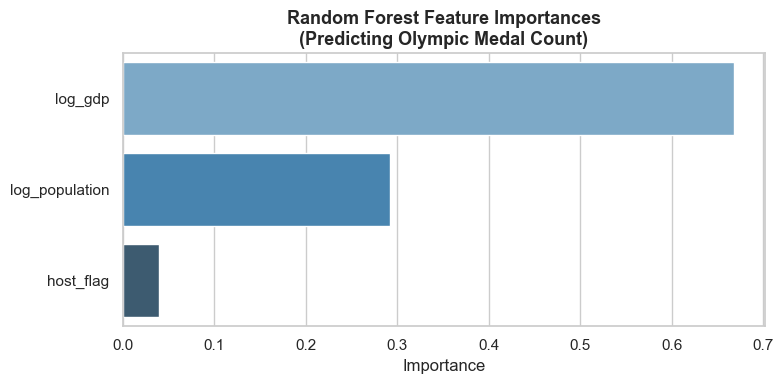


Feature importances:
       feature  importance
       log_gdp    0.668186
log_population    0.292355
     host_flag    0.039459


In [9]:

# 7. RANDOM FOREST — Medal Prediction & Feature Importance

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

features = ["log_gdp", "log_population", "host_flag"]
target = "medals_total"

rf_df = model_df[features + [target, "year"]].dropna()

# Temporal split: train on pre-2016 data, test on 2016–2020
train = rf_df[rf_df["year"] <= 2012]
test = rf_df[rf_df["year"] > 2012]

X_train, y_train = train[features], train[target]
X_test, y_test = test[features], test[target]

rf = RandomForestRegressor(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)

print("=== Random Forest — Test Set Performance ===")
print(f"Train size: {len(train)} | Test size: {len(test)}")
print(f"MAE:  {mae:.2f} medals")
print(f"RMSE: {rmse:.2f} medals")

# Feature importance chart
importance_df = pd.DataFrame({
    "feature": features,
    "importance": rf.feature_importances_,
}).sort_values("importance", ascending=False)

plt.figure(figsize=(8, 4))
sns.barplot(x="importance", y="feature", data=importance_df, palette="Blues_d")
plt.title("Random Forest Feature Importances\n(Predicting Olympic Medal Count)", fontsize=13, fontweight="bold")
plt.xlabel("Importance")
plt.ylabel("")
plt.tight_layout()
plt.savefig("../charts/feature_importances.png", dpi=150)
plt.show()

print("\nFeature importances:")
print(importance_df.to_string(index=False))
